# 01 - 读取 IDX 文件 & 数据预处理

## 目标
- 用 `open(..., 'rb')` 读取 MNIST 原始 IDX 格式
- 理解二进制 header：magic number → 维度 → 数据
- reshape：784 ↔ 28×28
- normalize：`x / 255.0`
- one-hot 编码标签
- matplotlib 可视化几张图片

## IDX 格式
| 偏移（字节） | 内容 |
|---|---|
| 0–3 | magic number（大端序） |
| 4–7 | 图片数量 |
| 8–11 | 行数（28） |
| 12–15 | 列数（28） |
| 16+ | 像素数据 |

magic number: 2051  (0x00000803)
  第3字节 0x08 = 数据类型 unsigned byte
  第4字节 0x03 = 维度数 3
图片数量: 60000
行数: 28
列数: 28
(60000,)


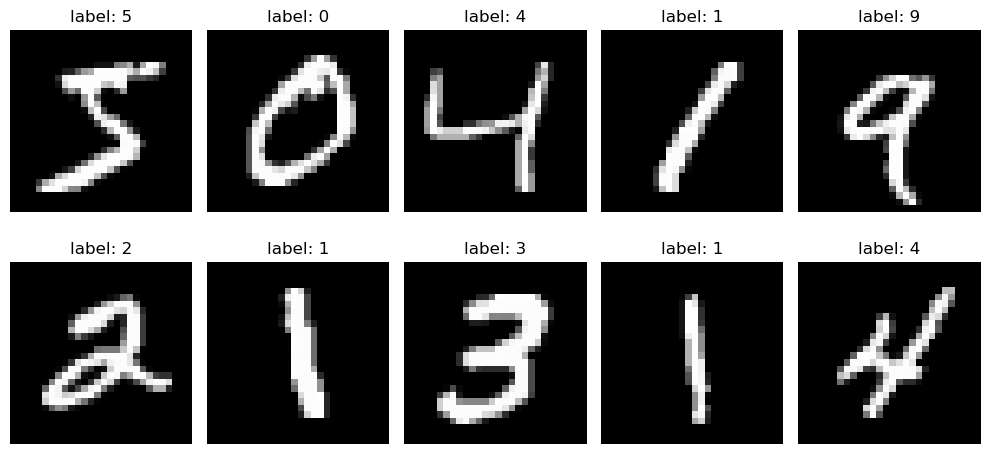

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import struct

"""
with ... as f: 是上下文管理器，进入block时打开文件，离开block时自动关闭文件，本质安全开关文件。后一个f会覆盖前面的
rb read binary
struct.unpack() 将二进制数据解包成 Python 对象，unpack是指按指定格式解析，返回一个元组：(2051, 60000, 28, 28)
> 表示大端序(big-endian)
I 表示 4 字节无符号整数
'>IIII' = 一次连续读 4 个整数，总共 16 字节
f.read(16) 从文件中读取前 16 字节数据，返回一个 bytes 对象
文件对象内部维护了一个位置指针，指向"下一次读取从哪里开始"，f.read返回bytes对象
np.frombuffer(f.read(), dtype=np.uint8)：从bytes对象中读取数据并转换为numpy数组
uint8：因为是灰度图像，每个像素值在0-255之间，使用8位无符号整数表示
"""



with open('../datasets/train-images.idx3-ubyte', 'rb') as f:
    magic_number, num_images, rows, cols = struct.unpack('>IIII', f.read(16))
    images = np.frombuffer(f.read(), dtype=np.uint8).reshape(num_images, rows, cols)

with open("../datasets/train-labels.idx1-ubyte", "rb") as f:
    magic, num = struct.unpack(">II", f.read(8))

    labels = np.frombuffer(f.read(), dtype=np.uint8)


"""
# 读取结果
print(f"magic number: {magic_number}  (0x{magic_number:08X})")
print(f"  第3字节 0x{(magic_number >> 8) & 0xFF:02X} = 数据类型 unsigned byte")
print(f"  第4字节 0x{magic_number & 0xFF:02X} = 维度数 3")
print(f"图片数量: {num_images}")
print(f"行数: {rows}")
print(f"列数: {cols}")
print(labels.shape)
"""

# 可视化前10张图片和标签
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(images[i], cmap='gray')
    ax.set_title(f'label: {labels[i]}')
    ax.axis('off')
plt.tight_layout()
plt.show()

"""
由于sigmoid的饱和特性，以及导数在输入较大或较小时趋近于0，导致梯度消失问题，训练困难。将像素值归一化到[0,1]范围内
归一化后优化也更容易
float32的两个原因：
  1. 除法会出小数。uint8 只能存 0~255 的整数，200 / 255 = 0.784...，用 uint8 放不下，直接给你截成 0。
  2. 后续计算需要梯度。权重是小数（0.01、-0.5 这种），矩阵乘法 x @ W 如果 x是整数类型，结果会被截断，梯度更新也会废掉。
  3. 选 float32 而不是 float64：训练时要处理 60000×784 的矩阵，float32 比 float64 省一半内存，而且MNIST这种任务 float32 精度完全够用。

最简单的全连接网络(MLP多层感知机)只能处理vector

"""
# 归一化 + 展平
x_train = images.astype(np.float32) / 255.0       # [0,255] → [0,1]
x_train = x_train.reshape(images.shape[0], -1)     # (60000,28,28) → (60000,784)